In [1]:
from fastai.vision.all import *
import timm


In [2]:
path = untar_data(URLs.PETS)/'images'

In [3]:
dls = ImageDataLoaders.from_name_func('.',get_image_files(path),valid_pct=0.2,seed=41,
                                      label_func=RegexLabeller(pat=r'^([^/]+)_\d+'),
                                      item_tfms=Resize(224))

In [6]:
categories=dls.vocab
categories

['Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British_Shorthair', 'Egyptian_Mau', 'Maine_Coon', 'Persian', 'Ragdoll', 'Russian_Blue', 'Siamese', 'Sphynx', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'boxer', 'chihuahua', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'miniature_pinscher', 'newfoundland', 'pomeranian', 'pug', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']

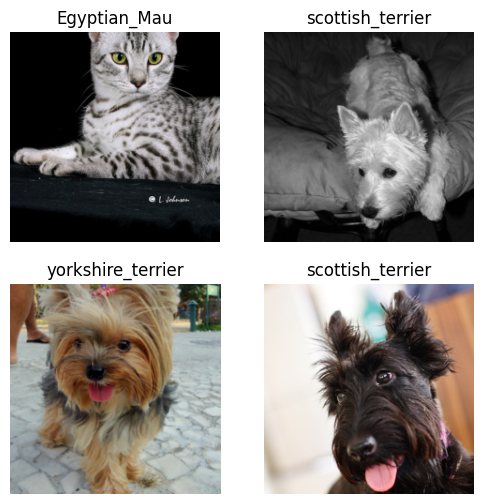

In [6]:
dls.show_batch(max_n=4)

In [7]:
learn=vision_learner(dls,resnet34,metrics=error_rate)

c:\Users\enesm\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\enesm\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to C:\Users\enesm/.cache\torch\hub\checkpoints\resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [01:46<00:00, 823kB/s] 


In [15]:
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,0.151317,0.344068,0.093369,00:50
1,0.131978,0.277699,0.075101,00:44
2,0.067915,0.248445,0.069012,00:57


In [13]:
from IPython.display import clear_output, DisplayHandle
def update_patch(self, obj):
    clear_output(wait=True)
    self.display(obj)
DisplayHandle.update = update_patch

In [14]:
learn.show_results

<bound method Learner.show_results of <fastai.learner.Learner object at 0x00000232FCE78670>>

In [16]:
timm.list_models('convnext*')

['convnext_atto',
 'convnext_atto_ols',
 'convnext_base',
 'convnext_femto',
 'convnext_femto_ols',
 'convnext_large',
 'convnext_large_mlp',
 'convnext_nano',
 'convnext_nano_ols',
 'convnext_pico',
 'convnext_pico_ols',
 'convnext_small',
 'convnext_tiny',
 'convnext_tiny_hnf',
 'convnext_xlarge',
 'convnext_xxlarge',
 'convnextv2_atto',
 'convnextv2_base',
 'convnextv2_femto',
 'convnextv2_huge',
 'convnextv2_large',
 'convnextv2_nano',
 'convnextv2_pico',
 'convnextv2_small',
 'convnextv2_tiny']

In [17]:
learn=vision_learner(dls,'convnext_tiny_in22k',metrics=error_rate).to_fp16()

c:\Users\enesm\AppData\Local\Programs\Python\Python310\lib\site-packages\timm\models\_factory.py:114: UserWarning: Mapping deprecated model name convnext_tiny_in22k to current convnext_tiny.fb_in22k.
  model = create_fn(


c:\Users\enesm\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:133: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\enesm\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [18]:
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,0.276049,0.208804,0.066306,00:59
1,0.209432,0.188637,0.054127,01:01
2,0.120845,0.172936,0.053451,00:59


In [20]:
learn.export('modelll.pkl')